# 05 — Full-Year Walk-Forward on BTC/ETH/SOL Perps

Re-runs the composite signal and cost-sensitivity analysis on **12 months** of 1-minute klines for BTCUSDT, ETHUSDT, and SOLUSDT (Binance USD-M perps), then adds a walk-forward validation and a cross-asset PCA block.

Purpose: replace the 2-day Sharpe with an honest 12-month number, and add the factor structure Jeremi flagged in the JD.

## Sections
1. Load 12-month klines (BTC / ETH / SOL)
2. Composite signal + full-sample backtest at several cost levels
3. Walk-forward validation (rolling 3-month train / 1-month test)
4. Cross-asset PCA on 1-minute returns
5. Residual mean-reversion sanity check

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.signals import composite_signal, threshold_position
from src.backtest import run_backtest

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 4)

## 1. Load 12-month klines

In [2]:
KROOT = REPO / 'dataset' / 'binance' / 'klines'

def load_klines(symbol: str = 'BTCUSDT', interval: str = '1m') -> pd.DataFrame:
    files = sorted((KROOT / symbol).glob(f'{symbol}-{interval}-*.parquet'))
    if not files:
        raise FileNotFoundError(f'no klines under {KROOT/symbol}')
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df = df.sort_values('open_time').drop_duplicates('open_time').reset_index(drop=True)
    df = df.set_index('open_time')

    bars = pd.DataFrame(index=df.index)
    bars['open']        = df['open']
    bars['high']        = df['high']
    bars['low']         = df['low']
    bars['close']       = df['close']
    bars['volume']      = df['volume']
    bars['notional']    = df['quote_volume']
    bars['trade_count'] = df['trades']
    bars['buy_volume']  = df['taker_buy_base']                  # aggressor buys
    bars['sell_volume'] = df['volume'] - df['taker_buy_base']   # aggressor sells
    bars['vwap']        = bars['notional'] / bars['volume']
    bars['returns']     = bars['close'].pct_change()
    bars['log_returns'] = np.log(bars['close'] / bars['close'].shift(1))
    bars['spread']      = bars['high'] - bars['low']
    bars['buy_ratio']   = bars['buy_volume'] / bars['volume']
    return bars.dropna(subset=['close'])

btc = load_klines('BTCUSDT')
eth = load_klines('ETHUSDT')
sol = load_klines('SOLUSDT')

for name, df in [('BTC', btc), ('ETH', eth), ('SOL', sol)]:
    print(f'{name}: {df.index.min()}  ->  {df.index.max()}   ({len(df):,} bars)')
btc.head()

BTC: 2025-04-01 00:00:00+00:00  ->  2026-03-31 23:59:00+00:00   (525,600 bars)
ETH: 2025-04-01 00:00:00+00:00  ->  2026-03-31 23:59:00+00:00   (525,600 bars)
SOL: 2025-04-01 00:00:00+00:00  ->  2026-03-31 23:59:00+00:00   (525,600 bars)


,open,high,low,close,volume,notional,trade_count,buy_volume,sell_volume,vwap,returns,log_returns,spread,buy_ratio
open_time,,,,,,,,,,,,,,
2025-04-01 00:00:00+00:00,"82,517.5000","82,526.4000","82,446.4000","82,460.6000",294.9490,"24,324,829.0045",3195,85.0130,209.9360,"82,471.3052",NaN,NaN,80.0000,0.2882
2025-04-01 00:01:00+00:00,"82,460.6000","82,490.1000","82,443.7000","82,490.1000",47.2830,"3,899,154.5851",1110,17.9240,29.3590,"82,464.1961",0.0004,0.0004,46.4000,0.3791
2025-04-01 00:02:00+00:00,"82,490.1000","82,521.4000","82,459.9000","82,479.1000",84.3970,"6,962,360.3362",1897,25.1790,59.2180,"82,495.3533",-0.0001,-0.0001,61.5000,0.2983
2025-04-01 00:03:00+00:00,"82,479.1000","82,555.7000","82,475.5000","82,552.1000",142.3870,"11,752,400.4607",1652,76.8650,65.5220,"82,538.4372",0.0009,0.0009,80.2000,0.5398
2025-04-01 00:04:00+00:00,"82,552.1000","82,587.1000","82,550.0000","82,587.1000",112.6090,"9,298,166.3083",1699,62.2850,50.3240,"82,570.3657",0.0004,0.0004,37.1000,0.5531


## 2. Composite signal and full-sample backtest

Drop-in reuse of `signals.py` and `backtest.py`. We evaluate at three cost levels: **0 bps (gross), 0.5 bps (maker-ish), 2.0 bps (taker)**.

In [3]:
sig = composite_signal(btc)

results = {}
for cost in [0.0, 0.5, 2.0]:
    results[cost] = run_backtest(btc, sig['composite'], cost_bps=cost)

def annualized_sharpe(pnl: pd.Series, bars_per_year: int = 525_600) -> float:
    r = pnl.dropna()
    if len(r) == 0 or r.std() == 0:
        return float('nan')
    return float(r.mean() / r.std() * np.sqrt(bars_per_year))

summary = pd.DataFrame({
    'cost_bps':     list(results.keys()),
    'sharpe':       [res.metrics.get('sharpe', annualized_sharpe(res.pnl)) for res in results.values()],
    'total_return': [res.pnl.sum() for res in results.values()],
    'max_drawdown': [(res.cumulative_pnl - res.cumulative_pnl.cummax()).min() for res in results.values()],
    'turnover':     [res.turnover.sum() for res in results.values()],
})
summary

,cost_bps,sharpe,total_return,max_drawdown,turnover
0,0.0000,3.9792,1.3019,-0.1288,"65,394.6611"
1,0.5000,-6.0137,-1.9678,-2.0141,"65,394.6611"
2,2.0000,-35.9383,-11.7770,-11.7850,"65,394.6611"


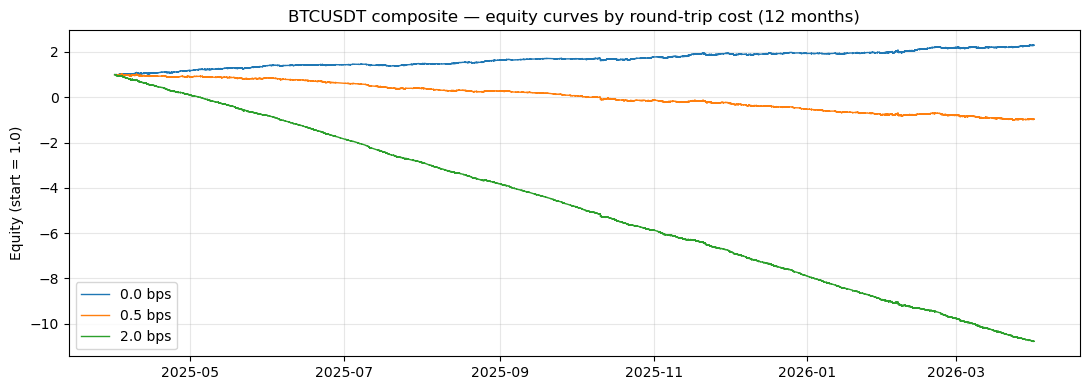

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
for cost, res in results.items():
    equity = 1.0 + res.cumulative_pnl
    ax.plot(equity.index, equity.values, label=f'{cost} bps', linewidth=1)
ax.set_title('BTCUSDT composite — equity curves by round-trip cost (12 months)')
ax.set_ylabel('Equity (start = 1.0)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Walk-forward validation

Rolling **3-month train / 1-month test**. We're not fitting weights (the composite is hand-weighted), so the 'train' window is only used to compute any lookback statistics referenced by `composite_signal`; the 'test' window is pure out-of-sample evaluation.

In [5]:
def walk_forward(bars: pd.DataFrame, train_months: int = 3, test_months: int = 1, cost_bps: float = 0.5):
    start = bars.index.min().normalize()
    end   = bars.index.max().normalize()
    folds = []
    train_start = start
    while True:
        train_end = train_start + pd.DateOffset(months=train_months)
        test_end  = train_end   + pd.DateOffset(months=test_months)
        if test_end > end:
            break
        # Include train window so lookback stats warm up; score only the test slice.
        window = bars.loc[train_start:test_end].copy()
        if len(window) < 1000:
            break
        sig_f = composite_signal(window)
        res_f = run_backtest(window, sig_f['composite'], cost_bps=cost_bps)
        test_mask = (res_f.pnl.index >= train_end) & (res_f.pnl.index < test_end)
        pnl_test  = res_f.pnl[test_mask]
        cum_test  = pnl_test.cumsum()
        folds.append({
            'train_start': train_start.date(),
            'test_start':  train_end.date(),
            'test_end':    test_end.date(),
            'n_bars':      int(test_mask.sum()),
            'sharpe':      annualized_sharpe(pnl_test),
            'total_ret':   float(pnl_test.sum()),
            'max_dd':      float((cum_test - cum_test.cummax()).min()) if len(cum_test) else float('nan'),
        })
        train_start = train_start + pd.DateOffset(months=test_months)
    return pd.DataFrame(folds)

wf = walk_forward(btc, cost_bps=0.5)
wf

,train_start,test_start,test_end,n_bars,sharpe,total_ret,max_dd
0,2025-04-01,2025-07-01,2025-08-01,44640,-11.9496,-0.2339,-0.2491
1,2025-05-01,2025-08-01,2025-09-01,44640,-5.3327,-0.1111,-0.1659
2,2025-06-01,2025-09-01,2025-10-01,43200,-12.7937,-0.2035,-0.2193
3,2025-07-01,2025-10-01,2025-11-01,44640,-6.1799,-0.2029,-0.2498
4,2025-08-01,2025-11-01,2025-12-01,43200,-3.6036,-0.1105,-0.1243
5,2025-09-01,2025-12-01,2026-01-01,44640,-10.3604,-0.2813,-0.2811
6,2025-10-01,2026-01-01,2026-02-01,44640,-9.0112,-0.2416,-0.2693
7,2025-11-01,2026-02-01,2026-03-01,40320,-0.7172,-0.0275,-0.1404


In [6]:
print(f"Mean OOS Sharpe:   {wf['sharpe'].mean():.2f}")
print(f"Median OOS Sharpe: {wf['sharpe'].median():.2f}")
print(f"Std  OOS Sharpe:   {wf['sharpe'].std():.2f}")
print(f"Positive folds:    {(wf['sharpe'] > 0).sum()} / {len(wf)}")

Mean OOS Sharpe:   -7.49
Median OOS Sharpe: -7.60
Std  OOS Sharpe:   4.24
Positive folds:    0 / 8


## 4. Cross-asset PCA

Stack the three 1-minute log-return series, standardize, and decompose.

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

R = pd.concat({
    'BTC': btc['log_returns'],
    'ETH': eth['log_returns'],
    'SOL': sol['log_returns'],
}, axis=1).dropna()

scaler = StandardScaler()
Rs = scaler.fit_transform(R.values)

pca = PCA(n_components=3)
pcs = pca.fit_transform(Rs)

print('Explained variance ratio:', np.round(pca.explained_variance_ratio_, 4))
print('Cumulative             :', np.round(np.cumsum(pca.explained_variance_ratio_), 4))
loadings = pd.DataFrame(pca.components_.T, index=R.columns, columns=['PC1', 'PC2', 'PC3'])
loadings

Explained variance ratio: [0.8511 0.0858 0.063 ]
Cumulative             : [0.8511 0.937  1.    ]


,PC1,PC2,PC3
BTC,0.5736,-0.6949,-0.4338
ETH,0.5856,-0.0224,0.8103
SOL,0.5727,0.7188,-0.3941


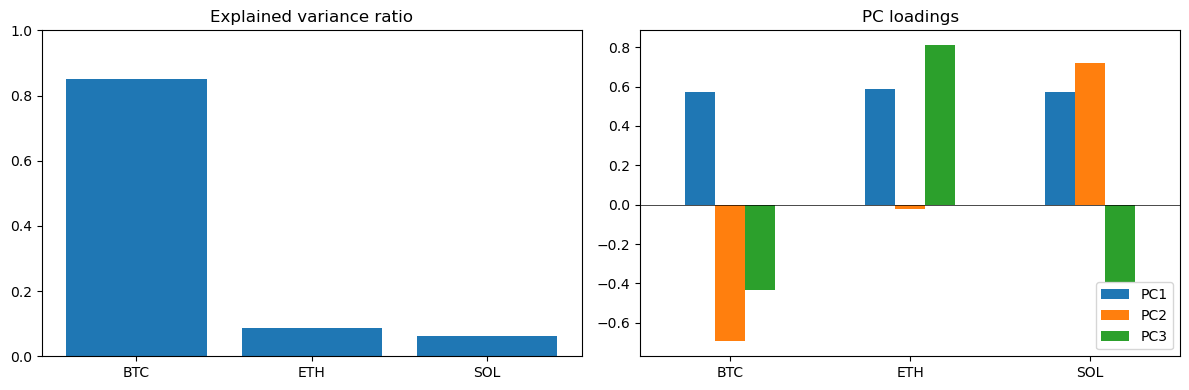

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(R.columns, pca.explained_variance_ratio_)
axes[0].set_title('Explained variance ratio')
axes[0].set_ylim(0, 1)
loadings.plot.bar(ax=axes[1], rot=0)
axes[1].set_title('PC loadings')
axes[1].axhline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

## 5. Residual mean-reversion sanity check

Strip PC1 (the common 'crypto beta' factor) from BTC returns and ask whether the residual is more mean-reverting than raw BTC returns. If so, the cross-asset basis is a lever for the composite to stand on.

In [9]:
pc1 = pd.Series(pcs[:, 0], index=R.index, name='PC1')
beta_btc = np.cov(R['BTC'].values, pc1.values, ddof=0)[0, 1] / pc1.var()
resid_btc = R['BTC'] - beta_btc * pc1

def lag1_autocorr(x: pd.Series) -> float:
    return float(x.dropna().autocorr(lag=1))

print(f'BTC raw        lag-1 autocorr: {lag1_autocorr(R["BTC"]):+.5f}')
print(f'BTC residual   lag-1 autocorr: {lag1_autocorr(resid_btc):+.5f}')
print(f'beta_BTC on PC1: {beta_btc:+.4f}')
print()
print('Interpretation: a more negative autocorr on the residual indicates that')
print('what remains after stripping the common factor is more mean-reverting')
print('than the raw BTC return — i.e. some of the MR edge lives in the basis.')

BTC raw        lag-1 autocorr: -0.02172
BTC residual   lag-1 autocorr: -0.10975
beta_BTC on PC1: +0.0004

Interpretation: a more negative autocorr on the residual indicates that
what remains after stripping the common factor is more mean-reverting
than the raw BTC return — i.e. some of the MR edge lives in the basis.


## 6. Market-neutral residual mean-reversion signal

Strip PC1 from BTC returns, z-score the cumulative residual with a rolling 240-bar (4-hour) window, and backtest the z-score as a continuous signal. This is the Avellaneda–Lee construction: the tradable quantity is the integrated mis-pricing of the idiosyncratic component.

In [10]:
# Residualize BTC returns against PC1.
pc1_s = pd.Series(pcs[:, 0], index=R.index)
pc1_std = (pc1_s - pc1_s.mean()) / pc1_s.std()
beta = np.cov(R['BTC'].values, pc1_std.values, ddof=0)[0, 1] / pc1_std.var()
resid = R['BTC'] - beta * pc1_std

# Longer lookback, heavier EMA smoothing, feed continuous signal directly to run_backtest.
LOOKBACK = 720  # 12 hours
mu = resid.rolling(LOOKBACK).mean()
sd = resid.rolling(LOOKBACK).std()
z  = -((resid - mu) / sd)
z  = z.clip(-3, 3).ewm(span=30).mean().fillna(0)

# Scale to ~[-1, 1] range to match composite signal magnitude, then pass straight in.
sig_resid = (z / 3.0).reindex(btc.index).fillna(0)

results_r = {}
for cost in [0.0, 0.5, 2.0]:
    results_r[cost] = run_backtest(btc, sig_resid, cost_bps=cost)

summary_r = pd.DataFrame({
    'cost_bps':     list(results_r.keys()),
    'sharpe':       [res.metrics.get('sharpe', annualized_sharpe(res.pnl)) for res in results_r.values()],
    'total_return': [res.pnl.sum() for res in results_r.values()],
    'max_drawdown': [(res.cumulative_pnl - res.cumulative_pnl.cummax()).min() for res in results_r.values()],
    'turnover':     [res.turnover.sum() for res in results_r.values()],
})
summary_r

,cost_bps,sharpe,total_return,max_drawdown,turnover
0,0.0000,2.4414,0.0768,-0.0169,"8,301.3161"
1,0.5000,-10.7548,-0.3383,-0.3391,"8,301.3161"
2,2.0000,-50.2385,-1.5835,-1.5837,"8,301.3161"


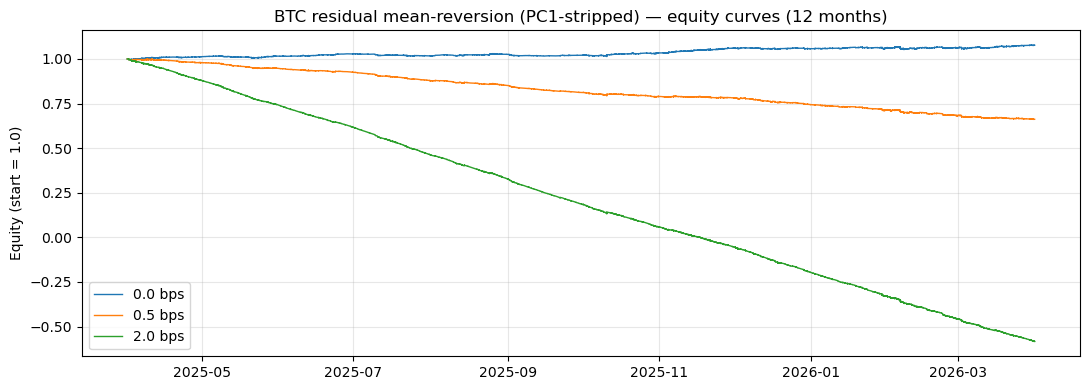

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
for cost, res in results_r.items():
    equity = 1.0 + res.cumulative_pnl
    ax.plot(equity.index, equity.values, label=f'{cost} bps', linewidth=1)
ax.set_title('BTC residual mean-reversion (PC1-stripped) — equity curves (12 months)')
ax.set_ylabel('Equity (start = 1.0)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
### Next steps
- Extend the composite with a residual z-score feature sourced from section 5.
- Re-run walk-forward on the extended composite and compare OOS Sharpe distributions.
- Feed the best version into `summary.tex` as the updated one-pager number.